In [11]:
# Cell 0 — Project Imports

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch

In [12]:
# Cell 1 — 방향 Marker를 가진 Synthetic Volume 생성

def create_directional_nifti() -> nib.Nifti1Image:
    """RAS 방향 marker를 포함한 synthetic NIfTI 생성."""
    
    # 서로 다른 길이를 가진 3D volume 생성
    volume_shape_ijk: tuple[int, int, int] = (
        40,
        50,
        60,
    )
    
    # 모든 voxel이 0인 빈 volume 생성
    directional_volume = np.zeros(
        volume_shape_ijk,
        dtype=np.float32,
    ) # [I=40, J=50, K=60]
    
    # Volume 중앙에 가상의 body 영역 배치
    directional_volume[
        8:32,
        10:40,
        12:48,
    ] = 100.0
    
    # +I 방향에 Right marker 배치
    directional_volume[
        31:36,
        22:28,
        27:33,
    ] = 300.0

    # +J 방향에 Anterior marker 배치
    directional_volume[
        17:23,
        39:44,
        27:33,
    ] = 500.0

    # +K 방향에 Superior marker 배치
    directional_volume[
        17:23,
        22:28,
        49:54,
    ] = 700.0
    
    # Voxel spacing settings
    voxel_spacing_ijk_mm: tuple[
        float,
        float,
        float,
    ] = (
        2.0,
        2.0,
        3.0,
    )

    # Voxel index를 RAS physical coordinate로 변환할 affine 생성
    affine_ijk_to_ras = np.eye(
        4,
        dtype=np.float64,
    )  # [4, 4]
    
    # Affine에 axis별 spacing 기록:
    affine_ijk_to_ras[0, 0] = voxel_spacing_ijk_mm[0]
    affine_ijk_to_ras[1, 1] = voxel_spacing_ijk_mm[1]
    affine_ijk_to_ras[2, 2] = voxel_spacing_ijk_mm[2]
    
    affine_ijk_to_ras[:3, 3] = np.asarray(
        [
            -40.0,
            -50.0,
            -90.0,
        ],
        dtype=np.float64,
    )
    
    # Directional array와 RAS affine 결합
    directional_nifti = nib.Nifti1Image(
        directional_volume,
        affine_ijk_to_ras,
    )
    
    return directional_nifti



# 방향 marker를 포함한 synthetic NIfTI 생성
orientation_nifti = create_directional_nifti()


# NIfTI에서 voxel array 추출
orientation_volume: np.ndarray = (
    orientation_nifti.get_fdata(
        dtype=np.float32,
    )
)  # [I=40, J=50, K=60]


# Affine으로부터 patient orientation 확인
orientation_axis_codes: tuple[
    str | None,
    ...,
] = nib.aff2axcodes(
    orientation_nifti.affine
)


print(
    "Volume shape:",
    orientation_volume.shape,
)

print(
    "Axis codes:",
    orientation_axis_codes,
)

print(
    "Body marker intensity:",
    orientation_volume[20, 25, 30],
)

print(
    "Right marker intensity:",
    orientation_volume[33, 25, 30],
)

print(
    "Anterior marker intensity:",
    orientation_volume[20, 41, 30],
)

print(
    "Superior marker intensity:",
    orientation_volume[20, 25, 51],
)

print("Affine:")
print(
    orientation_nifti.affine
)

Volume shape: (40, 50, 60)
Axis codes: ('R', 'A', 'S')
Body marker intensity: 100.0
Right marker intensity: 300.0
Anterior marker intensity: 500.0
Superior marker intensity: 700.0
Affine:
[[  2.   0.   0. -40.]
 [  0.   2.   0. -50.]
 [  0.   0.   3. -90.]
 [  0.   0.   0.   1.]]


In [13]:
# Cell 2 — Sagittal, Coronal과 Axial Slice 추출

def extract_three_anatomical_planes(
    volume_ijk: np.ndarray,              # [I, J, K]
    slice_index_ijk: tuple[int, int, int],
) -> tuple[
    np.ndarray,  # Sagittal [J, K]
    np.ndarray,  # Coronal [I, K]
    np.ndarray,  # Axial [I, J]
]:
    """지정한 voxel index를 지나는 세 anatomical plane 추출."""

    # 세 anatomical plane이 교차할 voxel index 분리
    slice_index_i, slice_index_j, slice_index_k = (
        slice_index_ijk
    )

    # I축 위치 고정
    sagittal_slice_jk: np.ndarray = volume_ijk[
        slice_index_i,
        :,
        :,
    ]  # [J, K]

    # J축 위치 고정
    coronal_slice_ik: np.ndarray = volume_ijk[
        :,
        slice_index_j,
        :,
    ]  # [I, K]

    # K축 위치 고정
    axial_slice_ij: np.ndarray = volume_ijk[
        :,
        :,
        slice_index_k,
    ]  # [I, J]

    return (
        sagittal_slice_jk,
        coronal_slice_ik,
        axial_slice_ij,
    )


# Volume 중앙에서 세 anatomical plane이 교차할 index 선택
center_slice_index_ijk: tuple[int, int, int] = (
    orientation_volume.shape[0] // 2,
    orientation_volume.shape[1] // 2,
    orientation_volume.shape[2] // 2,
)


# 중앙 voxel을 지나는 sagittal, coronal, axial slice 추출
(
    sagittal_slice_jk,
    coronal_slice_ik,
    axial_slice_ij,
) = extract_three_anatomical_planes(
    volume_ijk=orientation_volume,       # [I=40, J=50, K=60]
    slice_index_ijk=center_slice_index_ijk,
)


# 각 plane에 포함된 marker intensity 확인
#
# Sagittal: Body, Anterior, Superior
# Coronal:  Body, Right, Superior
# Axial:    Body, Right, Anterior
sagittal_unique_values = np.unique(
    sagittal_slice_jk
)

coronal_unique_values = np.unique(
    coronal_slice_ik
)

axial_unique_values = np.unique(
    axial_slice_ij
)


print(
    "Center index [I, J, K]:",
    center_slice_index_ijk,
)

print(
    "Sagittal shape [J, K]:",
    sagittal_slice_jk.shape,
)

print(
    "Coronal shape [I, K]:",
    coronal_slice_ik.shape,
)

print(
    "Axial shape [I, J]:",
    axial_slice_ij.shape,
)

print(
    "Sagittal intensities:",
    sagittal_unique_values,
)

print(
    "Coronal intensities:",
    coronal_unique_values,
)

print(
    "Axial intensities:",
    axial_unique_values,
)

Center index [I, J, K]: (20, 25, 30)
Sagittal shape [J, K]: (50, 60)
Coronal shape [I, K]: (40, 60)
Axial shape [I, J]: (40, 50)
Sagittal intensities: [  0. 100. 500. 700.]
Coronal intensities: [  0. 100. 300. 700.]
Axial intensities: [  0. 100. 300. 500.]


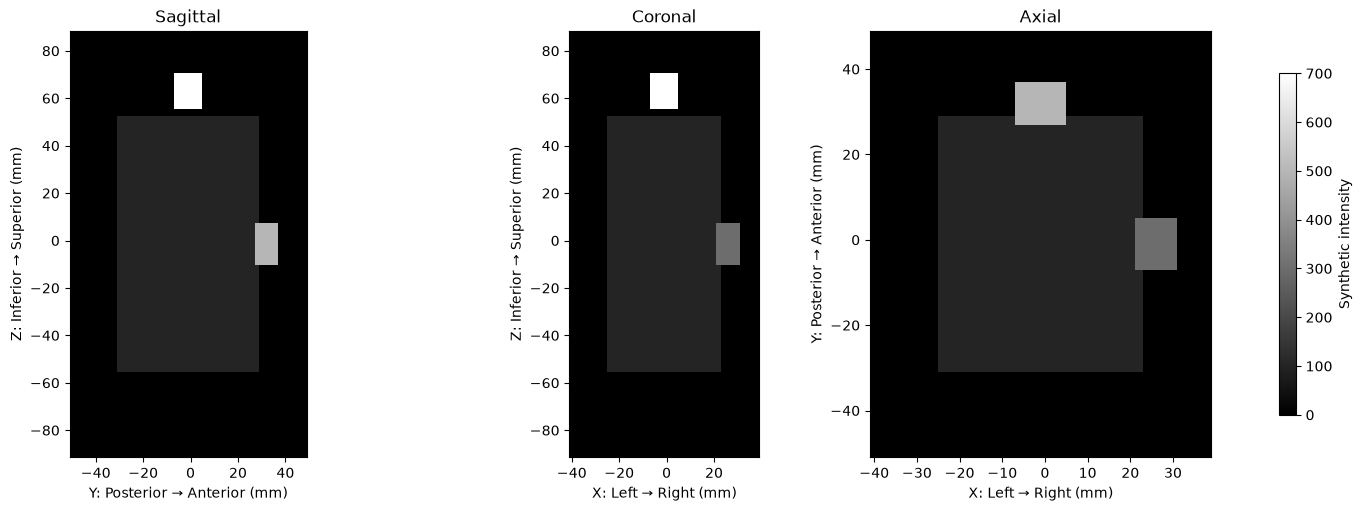

In [14]:
# Cell 3 — Physical Coordinate를 반영한 Three-Plane Viewer

def calculate_axis_edge_bounds(
    first_voxel_center_mm: float,
    voxel_spacing_mm: float,
    number_of_voxels: int,
) -> tuple[float, float]:
    """첫 voxel center와 spacing으로 physical edge 범위 계산."""

    # 첫 voxel 중심에서 spacing의 절반만큼 바깥쪽에 있는 첫 경계
    minimum_edge_mm = (
        first_voxel_center_mm
        - voxel_spacing_mm / 2
    )

    # 마지막 voxel 중심에서 spacing의 절반만큼 바깥쪽에 있는 마지막 경계
    maximum_edge_mm = (
        first_voxel_center_mm
        + number_of_voxels * voxel_spacing_mm
        - voxel_spacing_mm / 2
    )

    return (
        minimum_edge_mm,
        maximum_edge_mm,
    )


def show_three_plane_viewer(
    sagittal_slice_jk: np.ndarray,       # [J, K]
    coronal_slice_ik: np.ndarray,        # [I, K]
    axial_slice_ij: np.ndarray,          # [I, J]
    volume_shape_ijk: tuple[int, int, int],
    affine_ijk_to_ras: np.ndarray,       # [4, 4]
) -> None:
    """Sagittal, coronal과 axial slice를 RAS physical space로 표시."""

    # Volume의 axis별 Shape 분리
    size_i, size_j, size_k = volume_shape_ijk

    # Axis-aligned RAS affine에서 voxel spacing 추출
    spacing_i_mm = float(
        affine_ijk_to_ras[0, 0]
    )

    spacing_j_mm = float(
        affine_ijk_to_ras[1, 1]
    )

    spacing_k_mm = float(
        affine_ijk_to_ras[2, 2]
    )

    # Index [0, 0, 0] voxel center의 physical coordinate 추출
    origin_x_mm = float(
        affine_ijk_to_ras[0, 3]
    )

    origin_y_mm = float(
        affine_ijk_to_ras[1, 3]
    )

    origin_z_mm = float(
        affine_ijk_to_ras[2, 3]
    )

    # X축 전체 physical edge 범위 계산
    x_bounds_mm = calculate_axis_edge_bounds(
        first_voxel_center_mm=origin_x_mm,
        voxel_spacing_mm=spacing_i_mm,
        number_of_voxels=size_i,
    )

    # Y축 전체 physical edge 범위 계산
    y_bounds_mm = calculate_axis_edge_bounds(
        first_voxel_center_mm=origin_y_mm,
        voxel_spacing_mm=spacing_j_mm,
        number_of_voxels=size_j,
    )

    # Z축 전체 physical edge 범위 계산
    z_bounds_mm = calculate_axis_edge_bounds(
        first_voxel_center_mm=origin_z_mm,
        voxel_spacing_mm=spacing_k_mm,
        number_of_voxels=size_k,
    )

    # Sagittal, coronal과 axial 표시 영역 생성
    figure, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(15, 5),
        constrained_layout=True,
    )

    # Sagittal plane 표시
    #
    # Stored:  [J, K]
    # Display: [K, J]
    #
    # 가로축: physical Y
    # 세로축: physical Z
    sagittal_image = axes[0].imshow(
        sagittal_slice_jk.T,
        origin="lower",
        extent=(
            y_bounds_mm[0],
            y_bounds_mm[1],
            z_bounds_mm[0],
            z_bounds_mm[1],
        ),
        cmap="gray",
        vmin=0,
        vmax=700,
        interpolation="nearest",
        aspect="equal",
    )

    axes[0].set_title(
        "Sagittal"
    )

    axes[0].set_xlabel(
        "Y: Posterior → Anterior (mm)"
    )

    axes[0].set_ylabel(
        "Z: Inferior → Superior (mm)"
    )

    # Coronal plane 표시
    #
    # Stored:  [I, K]
    # Display: [K, I]
    #
    # 가로축: physical X
    # 세로축: physical Z
    axes[1].imshow(
        coronal_slice_ik.T,
        origin="lower",
        extent=(
            x_bounds_mm[0],
            x_bounds_mm[1],
            z_bounds_mm[0],
            z_bounds_mm[1],
        ),
        cmap="gray",
        vmin=0,
        vmax=700,
        interpolation="nearest",
        aspect="equal",
    )

    axes[1].set_title(
        "Coronal"
    )

    axes[1].set_xlabel(
        "X: Left → Right (mm)"
    )

    axes[1].set_ylabel(
        "Z: Inferior → Superior (mm)"
    )

    # Axial plane 표시
    #
    # Stored:  [I, J]
    # Display: [J, I]
    #
    # 가로축: physical X
    # 세로축: physical Y
    axes[2].imshow(
        axial_slice_ij.T,
        origin="lower",
        extent=(
            x_bounds_mm[0],
            x_bounds_mm[1],
            y_bounds_mm[0],
            y_bounds_mm[1],
        ),
        cmap="gray",
        vmin=0,
        vmax=700,
        interpolation="nearest",
        aspect="equal",
    )

    axes[2].set_title(
        "Axial"
    )

    axes[2].set_xlabel(
        "X: Left → Right (mm)"
    )

    axes[2].set_ylabel(
        "Y: Posterior → Anterior (mm)"
    )

    # 세 plane이 공유하는 intensity colorbar 추가
    figure.colorbar(
        sagittal_image,
        ax=axes,
        label="Synthetic intensity",
        shrink=0.8,
    )

    plt.show()


# 중앙에서 추출한 세 anatomical plane 표시
show_three_plane_viewer(
    sagittal_slice_jk=sagittal_slice_jk,  # [J=50, K=60]
    coronal_slice_ik=coronal_slice_ik,    # [I=40, K=60]
    axial_slice_ij=axial_slice_ij,        # [I=40, J=50]
    volume_shape_ijk=(
        orientation_volume.shape
    ),
    affine_ijk_to_ras=(
        orientation_nifti.affine
    ),  # [4, 4]
)

In [15]:
# Cell 4 — LPS Orientation과 Canonical RAS 복원

# RAS NIfTI에서 array & affine 추출
ras_volume: np.ndarray = orientation_nifti.get_fdata(
    dtype=np.float32,
)  # [I=40, J=50, K=60]

ras_affine: np.ndarray = (
    orientation_nifti.affine
)  # [4, 4]

# 원본 affine에서 현재 Array orientation 추출:
# [대응하는 physical axis, axis 증가 방향]
#
# [[0, +1],   I 증가 → physical +X
#  [1, +1],   J 증가 → physical +Y
#  [2, +1]]   K 증가 → physical +Z
ras_orientation: np.ndarray = (
    nib.orientations.io_orientation(
        ras_affine
    )
) # [3, 2]


# Target LPS orientation 정의:
target_lps_orientation: np.ndarray = (
    nib.orientations.axcodes2ornt(
        (
            "L", # I 증가 → Left
            "P", # J 증가 → Posterior
            "S", # K 증가 → Superior
        )
    )
)  # [3, 2]

# RAS Array를 LPS Array로 바꾸기 위한 orientation transform 계산
ras_to_lps_transform: np.ndarray = (
    nib.orientations.ornt_transform(
        ras_orientation,
        target_lps_orientation,
    )
) # [3, 2]

# RAS Array에 axis flip 적용:
lps_volume: np.ndarray = (
    nib.orientations.apply_orientation(
        ras_volume,
        ras_to_lps_transform,
    )
)  # [I=40, J=50, K=60]


# 새 LPS index를 기존 RAS index로 변환하는 affine 계산:
# LPS index -> 기존 RAS index
lps_index_to_ras_index_affine: np.ndarray = (
    nib.orientations.inv_ornt_aff(
        ras_to_lps_transform,
        ras_volume.shape,
    )
)  # [4, 4]

# LPS Array에 맞는 새 physical affine 계산:
#
# LPS index
#     ↓ lps_index_to_ras_index_affine
# RAS index
#     ↓ ras_affine
# Physical XYZ
lps_affine: np.ndarray = (
    ras_affine
    @ lps_index_to_ras_index_affine
)  # [4, 4]

# 뒤집힌 Array와 갱신된 affine 결합
lps_nifti = nib.Nifti1Image(
    lps_volume,
    lps_affine,
)


# 새 NIfTI가 실제로 LPS orientation인지 확인
lps_axis_codes: tuple[
    str | None,
    ...,
] = nib.aff2axcodes(
    lps_nifti.affine
)


# LPS NIfTI를 canonical RAS orientation으로 복원
#
# 내부 작업:
# 1. 현재 orientation 확인
# 2. 필요한 axis permutation과 flip 적용
# 3. 변경된 index에 맞게 affine 갱신
canonical_ras_nifti = nib.as_closest_canonical(
    lps_nifti
)


# Canonical RAS Array 추출
canonical_ras_volume: np.ndarray = (
    canonical_ras_nifti.get_fdata(
        dtype=np.float32,
    )
)  # [I=40, J=50, K=60]


# Canonical RAS affine 추출
canonical_ras_affine: np.ndarray = (
    canonical_ras_nifti.affine
)  # [4, 4]


# Canonical orientation 확인
canonical_axis_codes: tuple[
    str | None,
    ...,
] = nib.aff2axcodes(
    canonical_ras_affine
)


# Canonical 변환 후 원본 RAS Array 복원 여부 확인
canonical_array_matches_original = np.array_equal(
    canonical_ras_volume,
    ras_volume,
)


# Canonical 변환 후 원본 RAS affine 복원 여부 확인
canonical_affine_matches_original = np.allclose(
    canonical_ras_affine,
    ras_affine,
)


# 두 Array 사이의 가장 큰 voxel intensity 차이 계산
maximum_voxel_difference = np.max(
    np.abs(
        canonical_ras_volume
        - ras_volume
    )
).item()


print(
    "Original axis codes:",
    nib.aff2axcodes(ras_affine),
)

print(
    "Changed axis codes:",
    lps_axis_codes,
)

print(
    "Canonical axis codes:",
    canonical_axis_codes,
)

print("RAS-to-LPS transform:")
print(ras_to_lps_transform)

print("LPS affine:")
print(lps_affine)

print(
    "Canonical array matches original:",
    canonical_array_matches_original,
)

print(
    "Canonical affine matches original:",
    canonical_affine_matches_original,
)

print(
    "Maximum voxel difference:",
    maximum_voxel_difference,
)

Original axis codes: ('R', 'A', 'S')
Changed axis codes: ('L', 'P', 'S')
Canonical axis codes: ('R', 'A', 'S')
RAS-to-LPS transform:
[[ 0. -1.]
 [ 1. -1.]
 [ 2.  1.]]
LPS affine:
[[ -2.   0.   0.  38.]
 [  0.  -2.   0.  48.]
 [  0.   0.   3. -90.]
 [  0.   0.   0.   1.]]
Canonical array matches original: True
Canonical affine matches original: True
Maximum voxel difference: 0.0
